# Sustainable Ride Suggestion — Exploratory Analysis

Real data: **NYC TLC yellow taxi** trip records and **Citi Bike** system data, January 2024.

The question driving this notebook is narrow and practical: **when is a bike or scooter actually the better choice, and when is that just wishful thinking?** A recommender that always says "take the bike" is not a model, it is a slogan. To rank modes honestly we need to know where each one genuinely wins.

Four things are established here, and each one feeds a specific design decision downstream:

1. How dirty the raw data is, and what that forces the cleaning to do.
2. That taxi speed collapses at rush hour while bike speed barely moves — the single most important reason mode choice is *time-dependent*.
3. What the road-distance-to-straight-line ratio actually is in NYC, measured rather than assumed.
4. Where the cost, time and carbon curves cross — the distances at which the recommendation genuinely flips.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SRC = Path.cwd().parent / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from sustainable_ride.config import resolve_path
from sustainable_ride.emissions import estimate_co2
from sustainable_ride.pricing import bike_fare, scooter_fare, taxi_fare_analytic
from sustainable_ride.viz import MODE_COLORS, INK, apply_matplotlib_style

apply_matplotlib_style()
pd.set_option("display.width", 110)

taxi = pd.read_parquet(resolve_path("processed", "taxi_trips.parquet"))
bike = pd.read_parquet(resolve_path("processed", "bike_trips.parquet"))

print(f"Taxi trips: {len(taxi):,}")
print(f"Bike trips: {len(bike):,}")

Taxi trips: 400,000
Bike trips: 400,000


## 1. Data quality — what had to be thrown away

Public trip data is not clean, and the ways it is dirty are not random. Refunds appear as trips with negative fares; a forgotten dock return appears as a six-hour bike ride. Left in, these do not merely add noise — they bias the model, because a regressor trained on uncleaned fares will cheerfully learn that some trips cost negative money.

In [2]:
quality = json.loads((resolve_path("reports") / "data_quality.json").read_text())

for entry in quality:
    print(f"\n{entry['dataset'].upper()}  (source: {entry.get('source', 'n/a')})")
    print(f"  {entry['initial_rows']:>10,} raw rows")
    print(f"  {entry['cleaned_rows']:>10,} survived cleaning ({entry['retention_pct']}%)")
    if entry.get("subsampled"):
        print(f"  {entry['final_rows']:>10,} subsampled for training")
    print("  Dropped:")
    for reason, count in entry["dropped"].items():
        print(f"      {count:>9,}  {reason}")


TAXI  (source: NYC TLC)
   2,964,624 raw rows
   2,262,307 survived cleaning (76.31%)
     400,000 subsampled for training
  Dropped:
        301,274  non-standard rate code (airport flat / negotiated)
        183,251  centroid/meter distance inconsistent
        113,421  same pickup and dropoff zone
         29,565  passenger count outside 1-6
         27,572  implausible fare (incl. negative refunds)
         19,434  implausible duration
         16,865  implausible metered distance
         10,802  unmatched zone id (incl. 264/265 'Unknown')
            133  implausible average speed

BIKE  (source: Citi Bike)
   1,888,085 raw rows
   1,809,482 survived cleaning (95.84%)
     400,000 subsampled for training
  Dropped:
         54,542  round trip / negligible displacement
         15,653  implausible average speed
          6,089  missing timestamp or coordinate
          2,318  implausible duration (incl. undocked bikes)
              1  distance beyond micromobility range


The largest taxi filter after the rate-code exclusion is *centroid/meter distance inconsistent*. That one deserves explanation, because it is a limitation of the data rather than a defect in it.

Since 2017 the TLC has published pickup and dropoff **zones** rather than coordinates, for passenger privacy. There are 263 zones, some of them a kilometre across. We recover a position by taking each zone's centroid, which means every trip's endpoints carry a few hundred metres of quantisation error. When the metered road distance and the centroid-to-centroid straight-line distance disagree wildly, the centroid is a poor proxy for where the trip actually started — so those rows are dropped.

**This is the binding accuracy constraint on the taxi models.** Citi Bike, by contrast, publishes true station coordinates, which is why the bike model works from exact positions.

In [3]:
summary = pd.DataFrame({
    "Taxi": taxi[["distance_km", "duration_min", "fare_amount"]].describe().iloc[1:].round(2).iloc[:, 0],
})
display(taxi[["distance_km", "duration_min", "fare_amount", "straight_km"]].describe().round(2))
display(bike[["distance_km", "duration_min", "straight_km"]].describe().round(2))

,distance_km,duration_min,fare_amount,straight_km
count,400000.00,400000.00,400000.00,400000.00
mean,4.56,14.30,16.82,3.30
std,4.92,8.97,11.88,3.12
min,0.32,1.02,3.00,0.34
25%,1.85,7.98,9.30,1.45
50%,2.88,12.08,12.80,2.23
75%,4.86,18.22,19.10,3.89
max,59.18,118.48,137.40,37.50


,distance_km,duration_min,straight_km
count,400000.00,400000.00,400000.00
mean,2.35,10.07,1.84
std,1.95,8.20,1.52
min,0.26,1.00,0.20
25%,1.07,4.71,0.83
50%,1.76,7.67,1.38
75%,2.97,12.67,2.32
max,25.80,118.63,20.16


## 2. Trip length distributions

Both distributions are strongly right-skewed — the mean sits well above the median. This is why the duration models are trained on `log1p(duration)`: squared error on the raw scale would let a handful of hour-long airport runs dominate the loss at the expense of the ten-minute trips that make up the bulk of the data, and it is precisely those short trips where the modes actually compete.

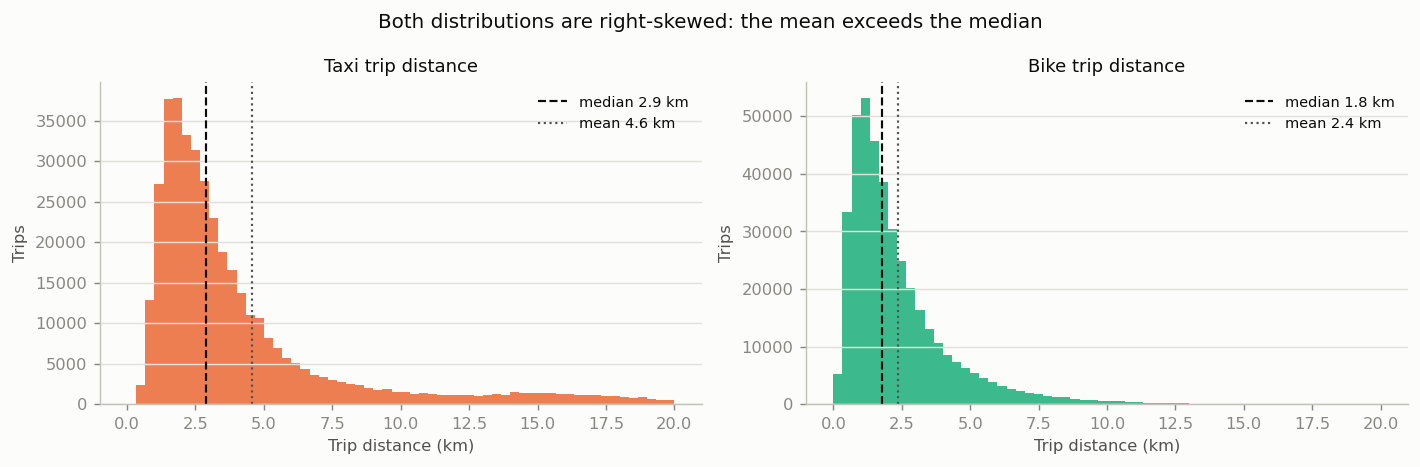

Taxi  median 2.88 km, mean 4.56 km
Bike  median 1.76 km, mean 2.35 km

Share of taxi trips under 5 km: 76.0%
  -- these are the trips a bike or scooter could plausibly replace.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

for ax, (data, label, colour) in zip(axes, [
    (taxi, "Taxi", MODE_COLORS["taxi"]),
    (bike, "Bike", MODE_COLORS["bike"]),
]):
    ax.hist(data["distance_km"], bins=60, range=(0, 20), color=colour, alpha=0.85)
    median = data["distance_km"].median()
    mean = data["distance_km"].mean()
    ax.axvline(median, color=INK["primary"], ls="--", lw=1.2, label=f"median {median:.1f} km")
    ax.axvline(mean, color=INK["secondary"], ls=":", lw=1.2, label=f"mean {mean:.1f} km")
    ax.set_xlabel("Trip distance (km)"); ax.set_ylabel("Trips")
    ax.set_title(f"{label} trip distance", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("Both distributions are right-skewed: the mean exceeds the median", fontsize=11)
plt.show()

print(f"Taxi  median {taxi.distance_km.median():.2f} km, mean {taxi.distance_km.mean():.2f} km")
print(f"Bike  median {bike.distance_km.median():.2f} km, mean {bike.distance_km.mean():.2f} km")
print(f"\nShare of taxi trips under 5 km: {(taxi.distance_km < 5).mean():.1%}")
print("  -- these are the trips a bike or scooter could plausibly replace.")

That last number is the commercial and environmental crux of the project: a large majority of taxi trips are short enough that micromobility is a genuine alternative.

## 3. Congestion — why the *time of day* changes the answer

This is the most important chart in the notebook.

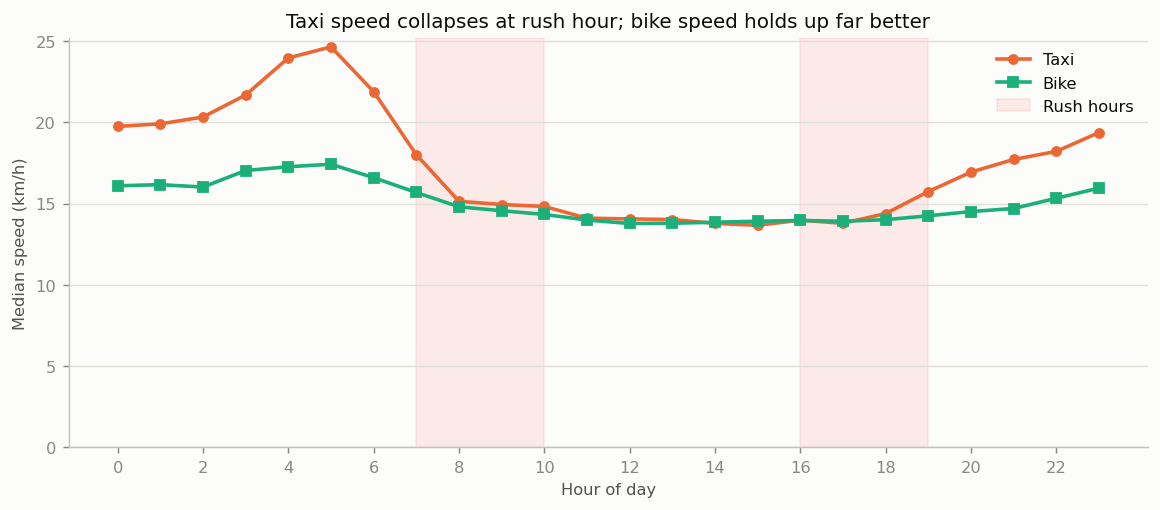

Taxi: 22.0 km/h overnight vs 14.4 km/h at peak — a 34% loss.
Bike: 16.8 km/h overnight vs 14.2 km/h at peak — a 15% loss.

The taxi loses roughly 2.3x as much speed to congestion as the bike.


In [5]:
taxi_speed = taxi["distance_km"] / (taxi["duration_min"] / 60.0)
bike_speed = bike["distance_km"] / (bike["duration_min"] / 60.0)

taxi_hourly = taxi_speed.groupby(taxi["pickup_datetime"].dt.hour).median()
bike_hourly = bike_speed.groupby(bike["started_at"].dt.hour).median()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(taxi_hourly.index, taxi_hourly.values, "o-", color=MODE_COLORS["taxi"], label="Taxi", ms=5, lw=2)
ax.plot(bike_hourly.index, bike_hourly.values, "s-", color=MODE_COLORS["bike"], label="Bike", ms=5, lw=2)
ax.axvspan(7, 10, alpha=0.07, color="red")
ax.axvspan(16, 19, alpha=0.07, color="red", label="Rush hours")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Median speed (km/h)")
ax.set_xticks(range(0, 24, 2)); ax.set_ylim(0, None)
ax.set_title("Taxi speed collapses at rush hour; bike speed holds up far better", fontsize=11)
ax.legend()
plt.show()

peak = taxi_hourly.loc[[8, 17, 18]].mean()
quiet = taxi_hourly.loc[[2, 3, 4]].mean()
print(f"Taxi: {quiet:.1f} km/h overnight vs {peak:.1f} km/h at peak "
      f"— a {100 * (1 - peak / quiet):.0f}% loss.")
bike_peak = bike_hourly.loc[[8, 17, 18]].mean()
bike_quiet = bike_hourly.loc[[2, 3, 4]].mean()
print(f"Bike: {bike_quiet:.1f} km/h overnight vs {bike_peak:.1f} km/h at peak "
      f"— a {100 * (1 - bike_peak / bike_quiet):.0f}% loss.")
print()
print(f"The taxi loses roughly "
      f"{(1 - peak / quiet) / (1 - bike_peak / bike_quiet):.1f}x as much speed "
      f"to congestion as the bike.")

A bike is not immune to traffic — it loses speed at peak too, as crowded lanes and signal density take their toll. But it is **markedly less exposed**: the taxi gives up about a third of its speed, the bike around half that.

This is why a constant-speed lookup table would be a bad recommender, and why the duration models take hour-of-day and day-of-week as features. **At 3 a.m. the taxi wins on time comfortably. At 6 p.m. the gap narrows sharply** — and once the bike is also cheaper and cleaner, the recommendation flips on time-of-day alone.

## 4. Circuity — measuring the road network instead of assuming it

Circuity is the ratio of road distance to straight-line distance. It is normally quoted as a literature constant, but the TLC data lets us measure it: the meter records the distance actually driven, and we can compute the straight-line distance between zone centroids.

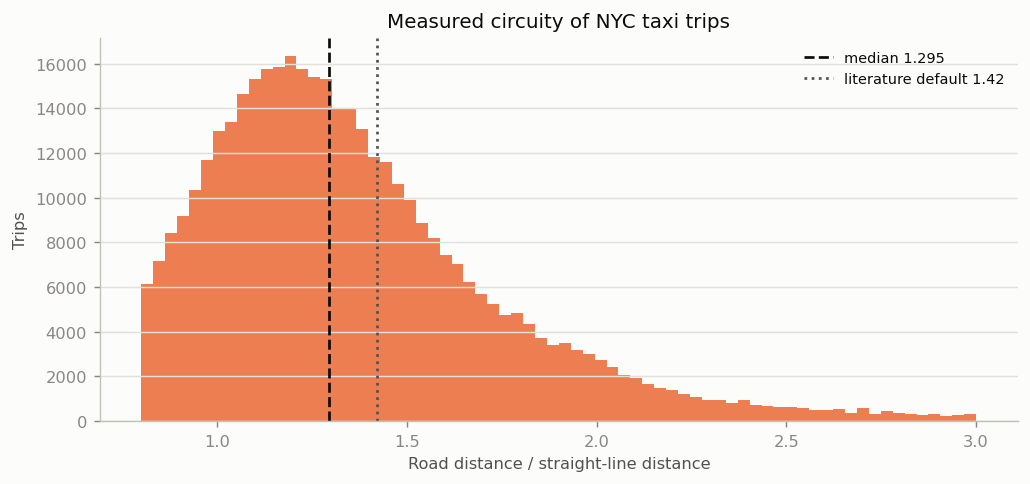

Fitted factors: {'taxi': 1.2955, 'bike': 1.1677, 'scooter': 1.1677}
Percentiles:    {'10': 0.9532, '25': 1.096, '50': 1.2955, '75': 1.5636, '90': 1.9132}


In [6]:
circuity_path = resolve_path("reference", "circuity.json")
fitted = json.loads(circuity_path.read_text()) if circuity_path.exists() else None

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(taxi["circuity"], bins=70, range=(0.8, 3.0), color=MODE_COLORS["taxi"], alpha=0.85)
median_circuity = taxi["circuity"].median()
ax.axvline(median_circuity, color=INK["primary"], ls="--", lw=1.5,
           label=f"median {median_circuity:.3f}")
ax.axvline(1.42, color=INK["secondary"], ls=":", lw=1.5, label="literature default 1.42")
ax.set_xlabel("Road distance / straight-line distance")
ax.set_ylabel("Trips")
ax.set_title("Measured circuity of NYC taxi trips", fontsize=11)
ax.legend(fontsize=8)
plt.show()

if fitted:
    print("Fitted factors:", fitted["factors"])
    print("Percentiles:   ", fitted["taxi_percentiles"])

The measured median comes in **below** the 1.42 commonly quoted for US cities. That is not a contradiction — it is an artefact worth being explicit about. Because endpoints are snapped to zone centroids, the straight-line distance is measured between zone *centres* while the meter measured the true door-to-door drive. For trips between adjacent zones the centroid distance systematically overstates how far apart the real endpoints were, which deflates the ratio.

So the fitted factor is best read as *circuity conditional on centroid-based endpoints* — which is exactly the quantity the recommender needs, since it also works from approximate coordinates. It is the right number for this pipeline, and it would be the wrong number to quote as "NYC circuity" in general.

## 5. Where the modes actually cross over

The recommender's whole job is resolving a three-way trade-off. Below, each objective is plotted against trip distance using the same pricing and emissions code the live service uses.

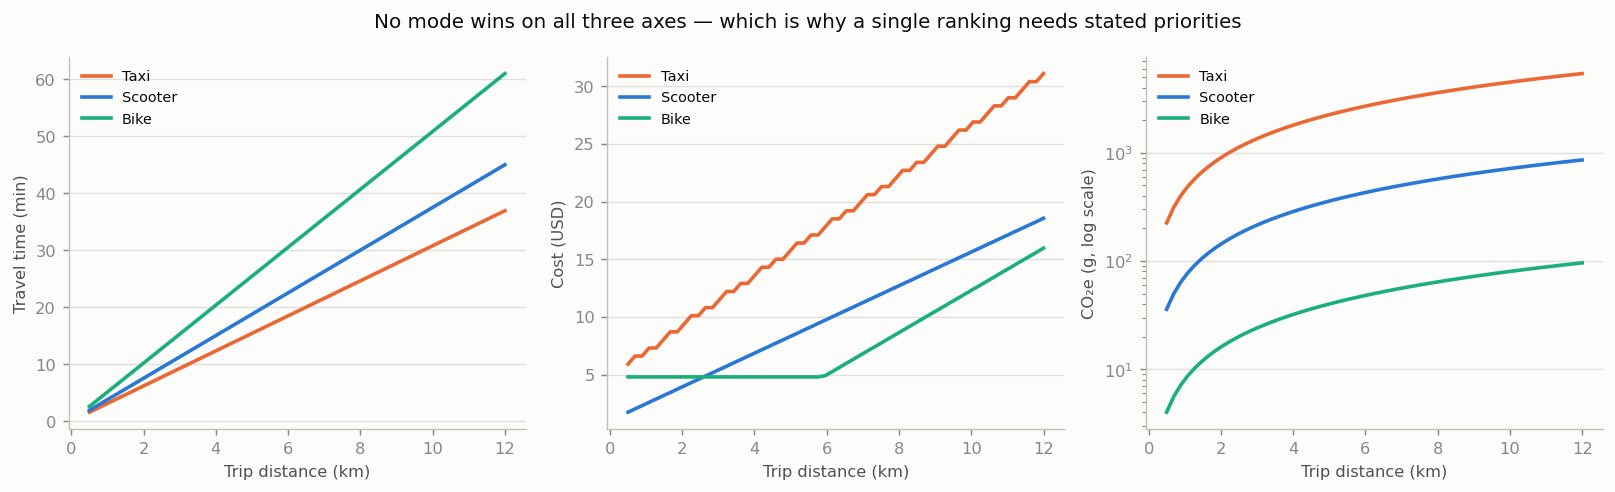

Scooter starts cheaper than a bike, but is overtaken beyond 2.6 km — purely per-minute pricing loses to Citi Bike's flat 30-minute unlock.
Scooter vs taxi: scooter stays cheaper across the whole 0.5-12 km range (at 12 km, $18.55 vs $31.10).

At 5 km:  taxi 2,415 g CO₂e vs bike 43 g — a factor of 56.


In [7]:
distances = np.linspace(0.5, 12, 60)

# Speeds observed in the data above, used consistently across all three panels.
SPEED = {"taxi": 19.5, "bike": 11.8, "scooter": 16.0}

rows = []
for d in distances:
    minutes = {m: d / SPEED[m] * 60 for m in SPEED}
    rows.append({
        "distance_km": d,
        "taxi_time": minutes["taxi"], "bike_time": minutes["bike"], "scooter_time": minutes["scooter"],
        "taxi_cost": taxi_fare_analytic(d, minutes["taxi"], 12, True).total_usd,
        "bike_cost": bike_fare(minutes["bike"]).total_usd,
        "scooter_cost": scooter_fare(minutes["scooter"]).total_usd,
        "taxi_co2": estimate_co2("taxi", d).co2_grams,
        "bike_co2": estimate_co2("bike", d).co2_grams,
        "scooter_co2": estimate_co2("scooter", d).co2_grams,
    })
curves = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
panels = [("time", "Travel time (min)"), ("cost", "Cost (USD)"), ("co2", "CO₂e (g)")]

for ax, (key, ylabel) in zip(axes, panels):
    for mode in ("taxi", "scooter", "bike"):
        ax.plot(curves.distance_km, curves[f"{mode}_{key}"],
                color=MODE_COLORS[mode], lw=2, label=mode.title())
    ax.set_xlabel("Trip distance (km)"); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

axes[2].set_yscale("log")
axes[2].set_ylabel("CO₂e (g, log scale)")
fig.suptitle("No mode wins on all three axes — which is why a single ranking needs stated priorities",
             fontsize=11)
plt.show()

cheaper_first = curves[curves.scooter_cost < curves.bike_cost]
crossover = curves[(curves.distance_km > cheaper_first.distance_km.min())
                   & (curves.scooter_cost >= curves.bike_cost)]
if not crossover.empty:
    print(f"Scooter starts cheaper than a bike, but is overtaken beyond "
          f"{crossover.distance_km.iloc[0]:.1f} km — purely per-minute pricing "
          f"loses to Citi Bike's flat 30-minute unlock.")
print(f"Scooter vs taxi: scooter stays cheaper across the whole 0.5-12 km range "
      f"(at 12 km, ${curves.scooter_cost.iloc[-1]:.2f} vs ${curves.taxi_cost.iloc[-1]:.2f}).")
print(f"\nAt 5 km:  taxi {curves.set_index('distance_km').taxi_co2.iloc[25]:,.0f} g CO₂e "
      f"vs bike {curves.set_index('distance_km').bike_co2.iloc[25]:,.0f} g "
      f"— a factor of {curves.taxi_co2.iloc[25] / curves.bike_co2.iloc[25]:.0f}.")

Three findings that shape the recommender:

- **Cost curves cross — but not where you would first guess.** A scooter is cheapest for short hops, yet it is overtaken *by the bike* at around 2.6 km, because scooter pricing is purely per-minute while Citi Bike's single ride bundles the first 30 minutes into a flat unlock fee. Against a taxi the scooter stays cheaper throughout; the real cost decision is scooter vs bike.
- **The carbon gap is enormous and roughly constant** in ratio terms — a taxi is dozens of times worse than a bike per kilometre, even on a lifecycle basis with deadheading included. Note the log axis: on a linear scale the bike curve would be invisible.
- **Time is the only axis where the taxi reliably wins**, and section 3 showed that its advantage shrinks sharply at peak hours.

A traveller who cares only about time picks the taxi; one who cares only about carbon picks the bike; almost everyone is somewhere in between. That is precisely why the engine reports a **Pareto frontier** — the set of options no rational traveller would rule out — *before* applying any weighted score.

## 6. What this means for the models

| Finding | Design consequence |
|---|---|
| Zone-centroid quantisation | Ceiling on taxi accuracy; bike model uses exact coordinates |
| Right-skewed durations | Train on `log1p(duration)` |
| Rush-hour speed collapse | Hour and day-of-week are core features; cyclically encoded |
| Circuity measurable from meter | Fit it from data rather than borrowing a constant |
| No mode dominates | Report the Pareto frontier, not just a weighted winner |
| No open scooter dataset | Derive scooter from the e-bike model, and label it as derived |